imports

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.io import read_image

In [2]:
transform=transforms.Compose([
    transforms.ToTensor()
])
train_dataset=datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)
test_dataset=train_dataset=datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform
)

classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

Files already downloaded and verified


c:\Users\Hammad Ali Shah\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


In [3]:
train_loader=DataLoader(train_dataset, shuffle=True, batch_size=64)
test_loader=DataLoader(test_dataset, shuffle=False, batch_size=64)

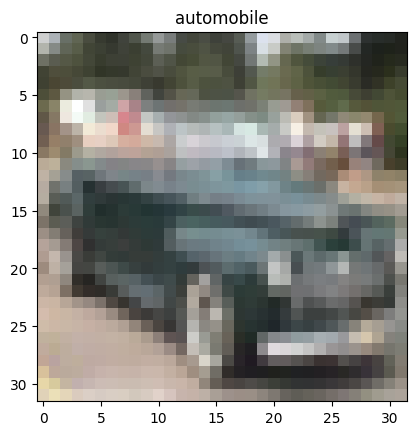

In [49]:
images, labels = next(iter(train_loader))
plt.imshow(images[0].permute(1,2,0))
plt.title(classes[labels[0]])
plt.show()

In [5]:
class CNNmodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone=nn.Sequential(
            nn.Conv2d(3,16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*4, 128),
            nn.ReLU(),
            nn.Linear(128,10)
        )
    
    def forward(self, x):
        x=self.backbone(x)
        x=self.classifier(x)
        return x
        

In [6]:
device=torch.device('cuda')
model=CNNmodel().to(device)
criteration=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)


In [7]:
for epoch in range(100):
    runningloss=0
    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        prediction=model(images)
        loss=criteration(prediction,labels)
        loss.backward()
        optimizer.step()
        runningloss+=loss.item()
    batchloss=runningloss/len(train_loader)
    print(f'epoch: {epoch+1}/100')
    print(f'loss: {batchloss}')

epoch: 1/100
loss: 2.043720596155543
epoch: 2/100
loss: 1.6733979123413183
epoch: 3/100
loss: 1.5176138908240446
epoch: 4/100
loss: 1.4196830828478382
epoch: 5/100
loss: 1.3559472014190286
epoch: 6/100
loss: 1.2945118144059637
epoch: 7/100
loss: 1.2348059358870147
epoch: 8/100
loss: 1.186868981950602
epoch: 9/100
loss: 1.126979635399618
epoch: 10/100
loss: 1.0554521641913492
epoch: 11/100
loss: 1.0074877792103276
epoch: 12/100
loss: 0.9517244472625149
epoch: 13/100
loss: 0.9179253955935217
epoch: 14/100
loss: 0.8472203035263499
epoch: 15/100
loss: 0.812161587226163
epoch: 16/100
loss: 0.7526549742479992
epoch: 17/100
loss: 0.7106396533121728
epoch: 18/100
loss: 0.6595203212112378
epoch: 19/100
loss: 0.60911471031274
epoch: 20/100
loss: 0.5551248530673373
epoch: 21/100
loss: 0.5135883032136662
epoch: 22/100
loss: 0.4576573969831892
epoch: 23/100
loss: 0.4222915690795631
epoch: 24/100
loss: 0.38107787680094407
epoch: 25/100
loss: 0.3347415161930072
epoch: 26/100
loss: 0.31022890339231796

In [8]:
torch.cuda.empty_cache()

In [ ]:
model.eval()
runningloss=0
with torch.no_grad():
    for images, labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        prediction=model(images)
        loss=criteration(prediction, labels)
        runningloss+=loss.item()
    averageloss=runningloss/len(test_dataset)
print(f'loss: {loss}')


loss: 2.6336238079238683e-05


In [ ]:
image=read_image("./cat2.png")
transofrmed=transforms.Compose(
    [
        transforms.Resize((32,32)),
        transforms.ConvertImageDtype(torch.float),
    ]
)
timg=transofrmed(image)
timg=timg.to(device).unsqueeze(0)
print(timg.shape)
softmax=nn.Softmax(dim=1)
predict=softmax(model(timg))
classs=torch.argmax(predict, dim=1).item()
print(classes[classs])

torch.Size([1, 3, 32, 32])
frog
